## Классная работа

In [6]:
import torch
import torch.optim as optim

import numpy as np

from random import randint
import matplotlib.pyplot as plt

#### Объясление функции модели

In [5]:
def model(X, w):
    """обычная линейная модель"""
    return X @ w

#### Подготовка датасета

In [6]:
N = 2
w = torch.FloatTensor(N).uniform_(-1e-5, 1e-5)  # создание случайных весовых коэффициентов
w.requires_grad_(True)  # потому что нам надо будет считать градиенты
x = torch.arange(0, 3, 0.1)

In [7]:
y_train = 0.5 * x + 0.2 * torch.sin(2*x) - 3.0  # функция, которую будем аппроксимировать
x_train = torch.tensor([[_x ** _n for _n in range(N)] for _x in x])  # потому что у нас еще есть bais

#### Задание параметров обучения

In [ ]:
total = len(x)
lr = torch.tensor([0.1, 0.01])
loss_func = torch.nn.L1Loss()  # функция потерь
optimizer = optim.Adam(params=[w], lr=0.01)  # оптимизатор

#### Обучение

In [9]:
for _ in range(1000):
    k = randint(0, total-1)
    y = model(x_train[k], w) 
    loss = loss_func(y, y_train[k])

    loss.backward()  # вычисляем производные (градиент)
    # w.data = w.data - lr * w.grad
    # w.grad.zero_()
    optimizer.step()
    optimizer.zero_grad()  # для обнуления градиентов в графе

#### Оценка обучения

In [12]:
print(f'Веса после обучения: {w}')
predict = model(x_train, w)
final_loss = loss_func(predict, y)
print(f'Средний эмпирический риск: {final_loss}')

Веса после обучения: tensor([-2.7309,  0.3606], requires_grad=True)
Средний эмпирический риск: 0.3080390989780426


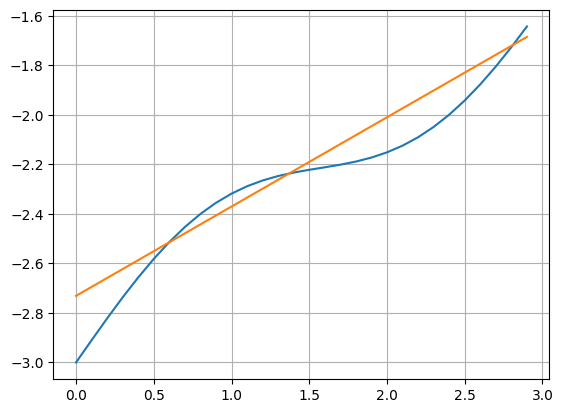

In [13]:
plt.plot(x, y_train.numpy())
plt.plot(x, predict.data.numpy())
plt.grid()
plt.show()

## Домашняя работа

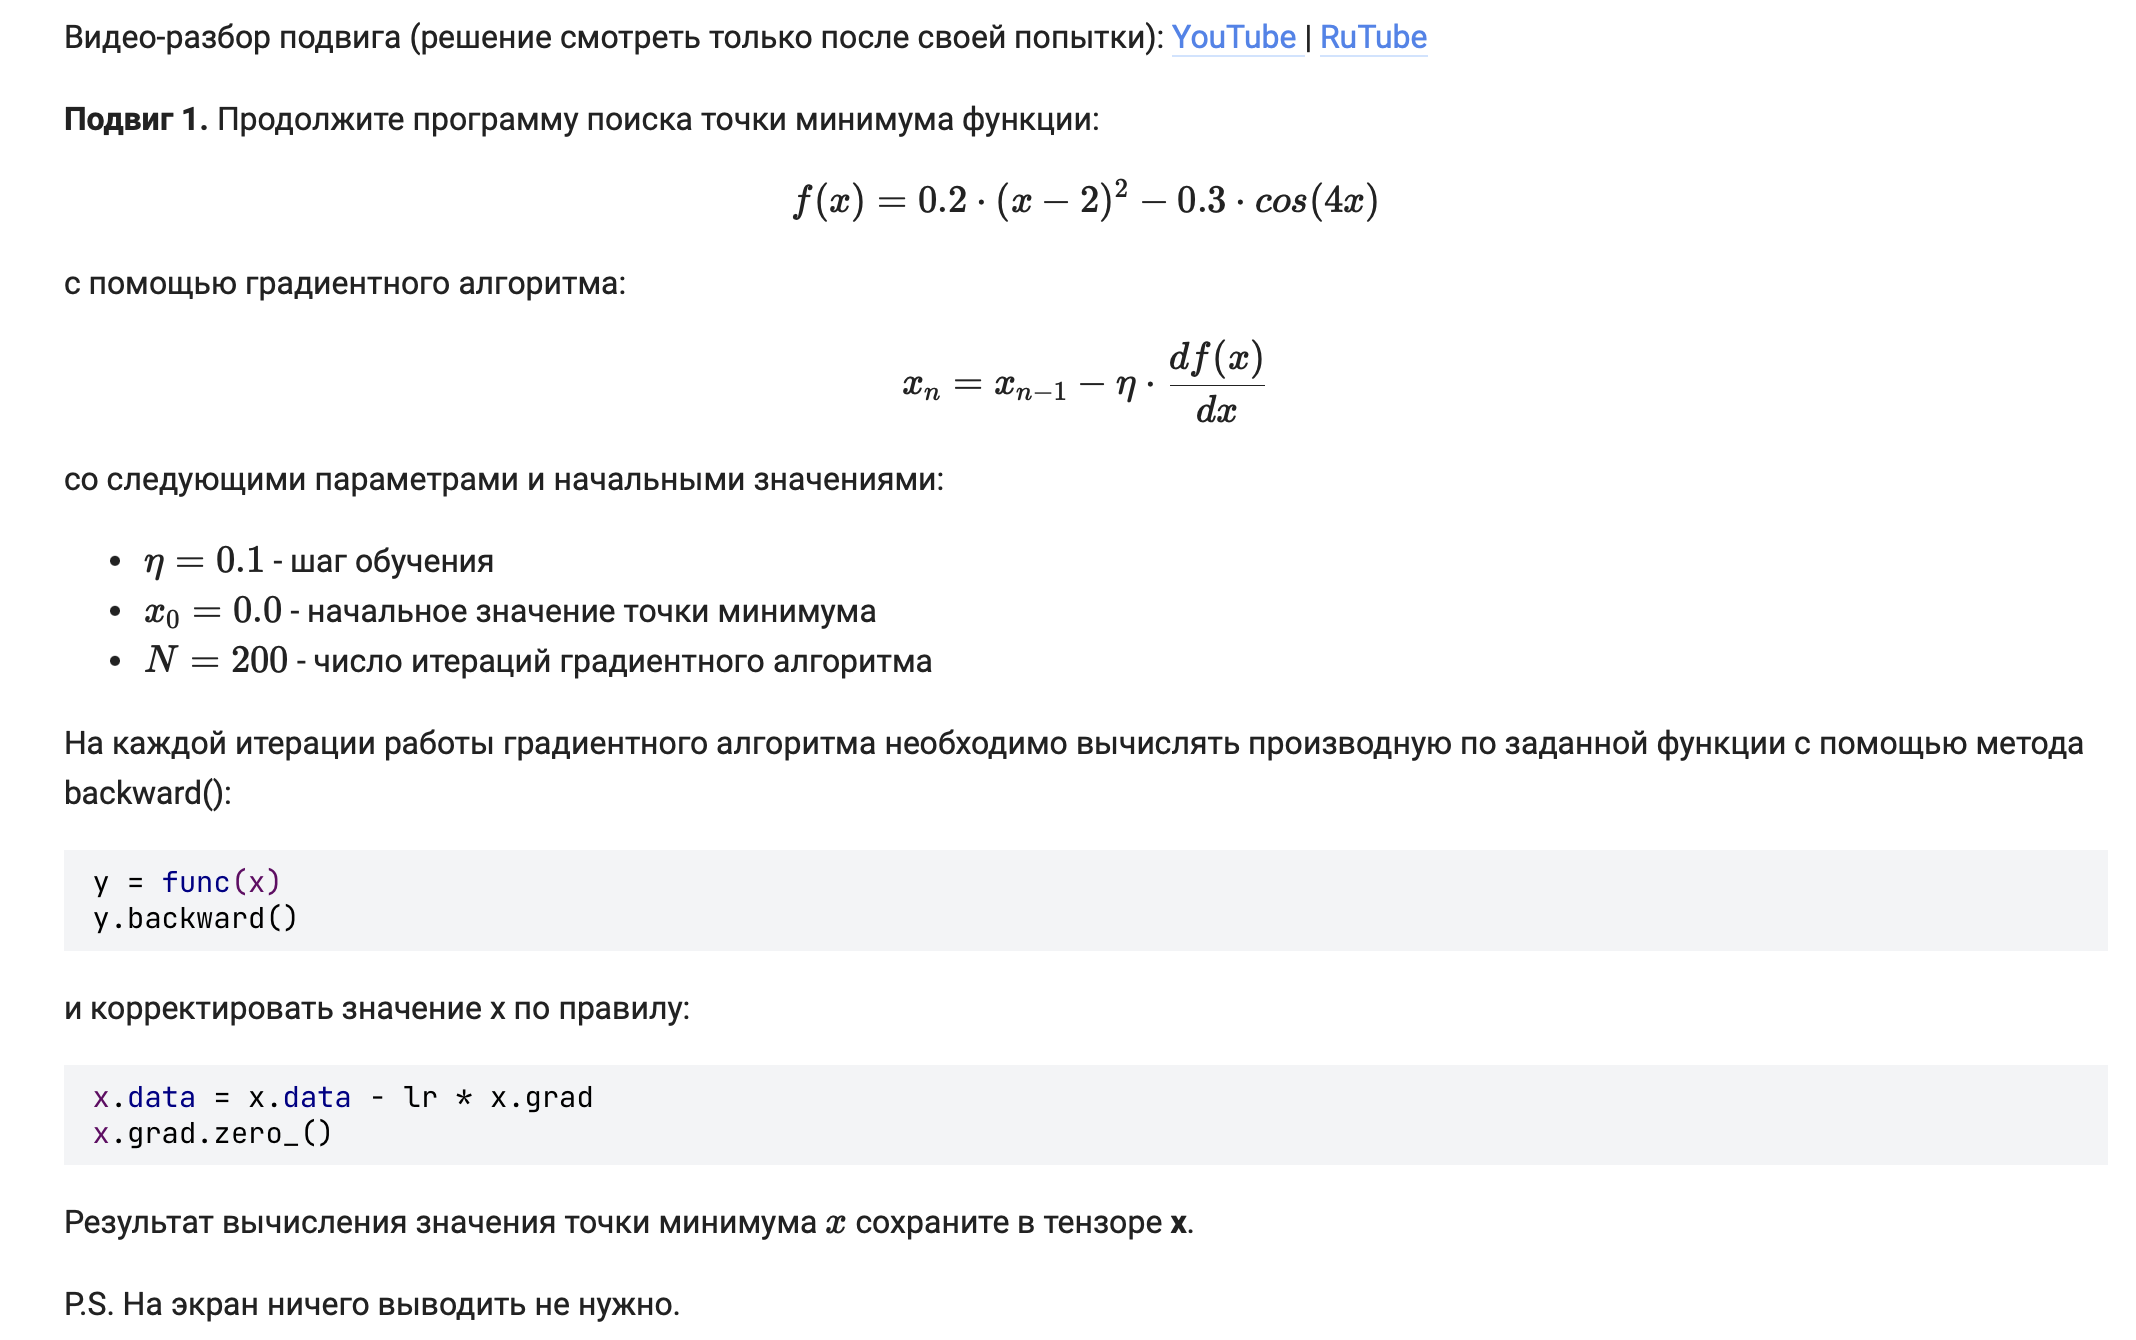

In [3]:
def func(x):
    return 0.2 * (x - 2) ** 2 - 0.3 * torch.cos(4 * x)


x0 = 0.0 # начальное значение точки минимума
lr = 0.1 # шаг обучения
N = 200 # число итераций градиентного алгоритма

x = torch.tensor([x0], requires_grad=True)

for i in range(N):
    y = func(x)
    y.backward()

    x.data -= lr * x.grad
    x.grad.zero_()

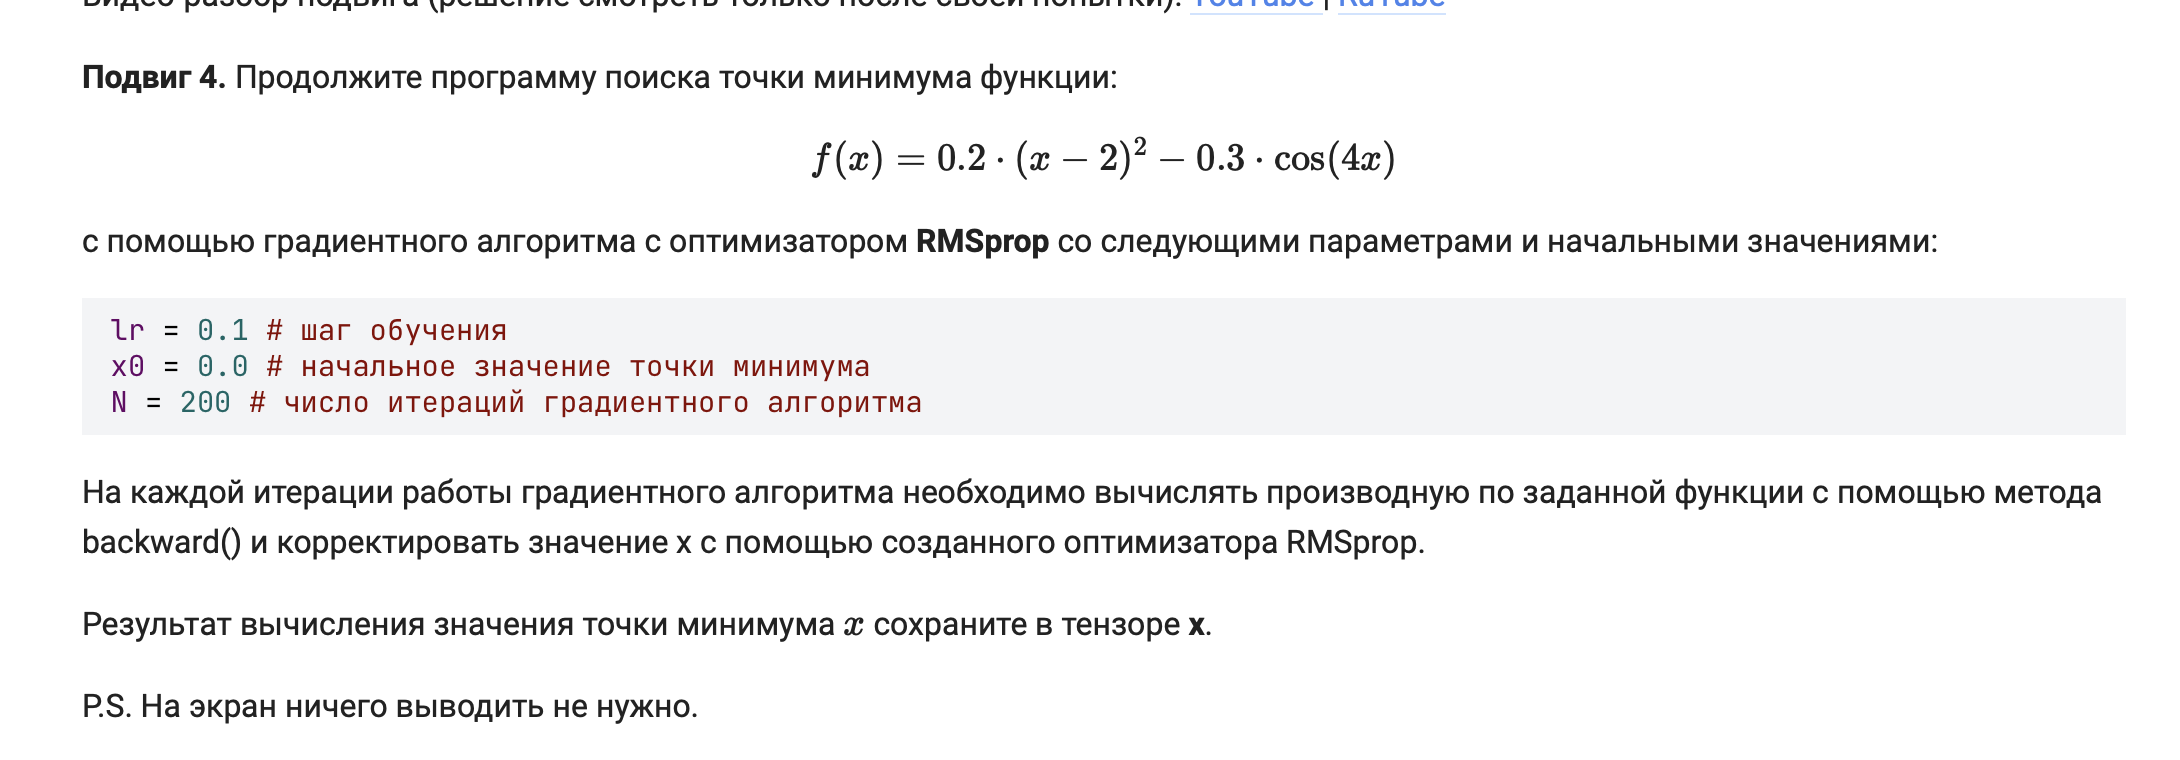

In [5]:
def func(x):
    return 0.2 * (x - 2) ** 2 - 0.3 * torch.cos(4 * x)


lr = 0.1 # шаг обучения
x0 = 0.0 # начальное значение точки минимума
N = 200 # число итераций градиентного алгоритма

x = torch.tensor([x0], requires_grad=True)

optimizer = optim.RMSprop(params=[x], lr=lr)
for i in range(N):
    y = func(x)
    y.backward()

    optimizer.step()
    optimizer.zero_grad()

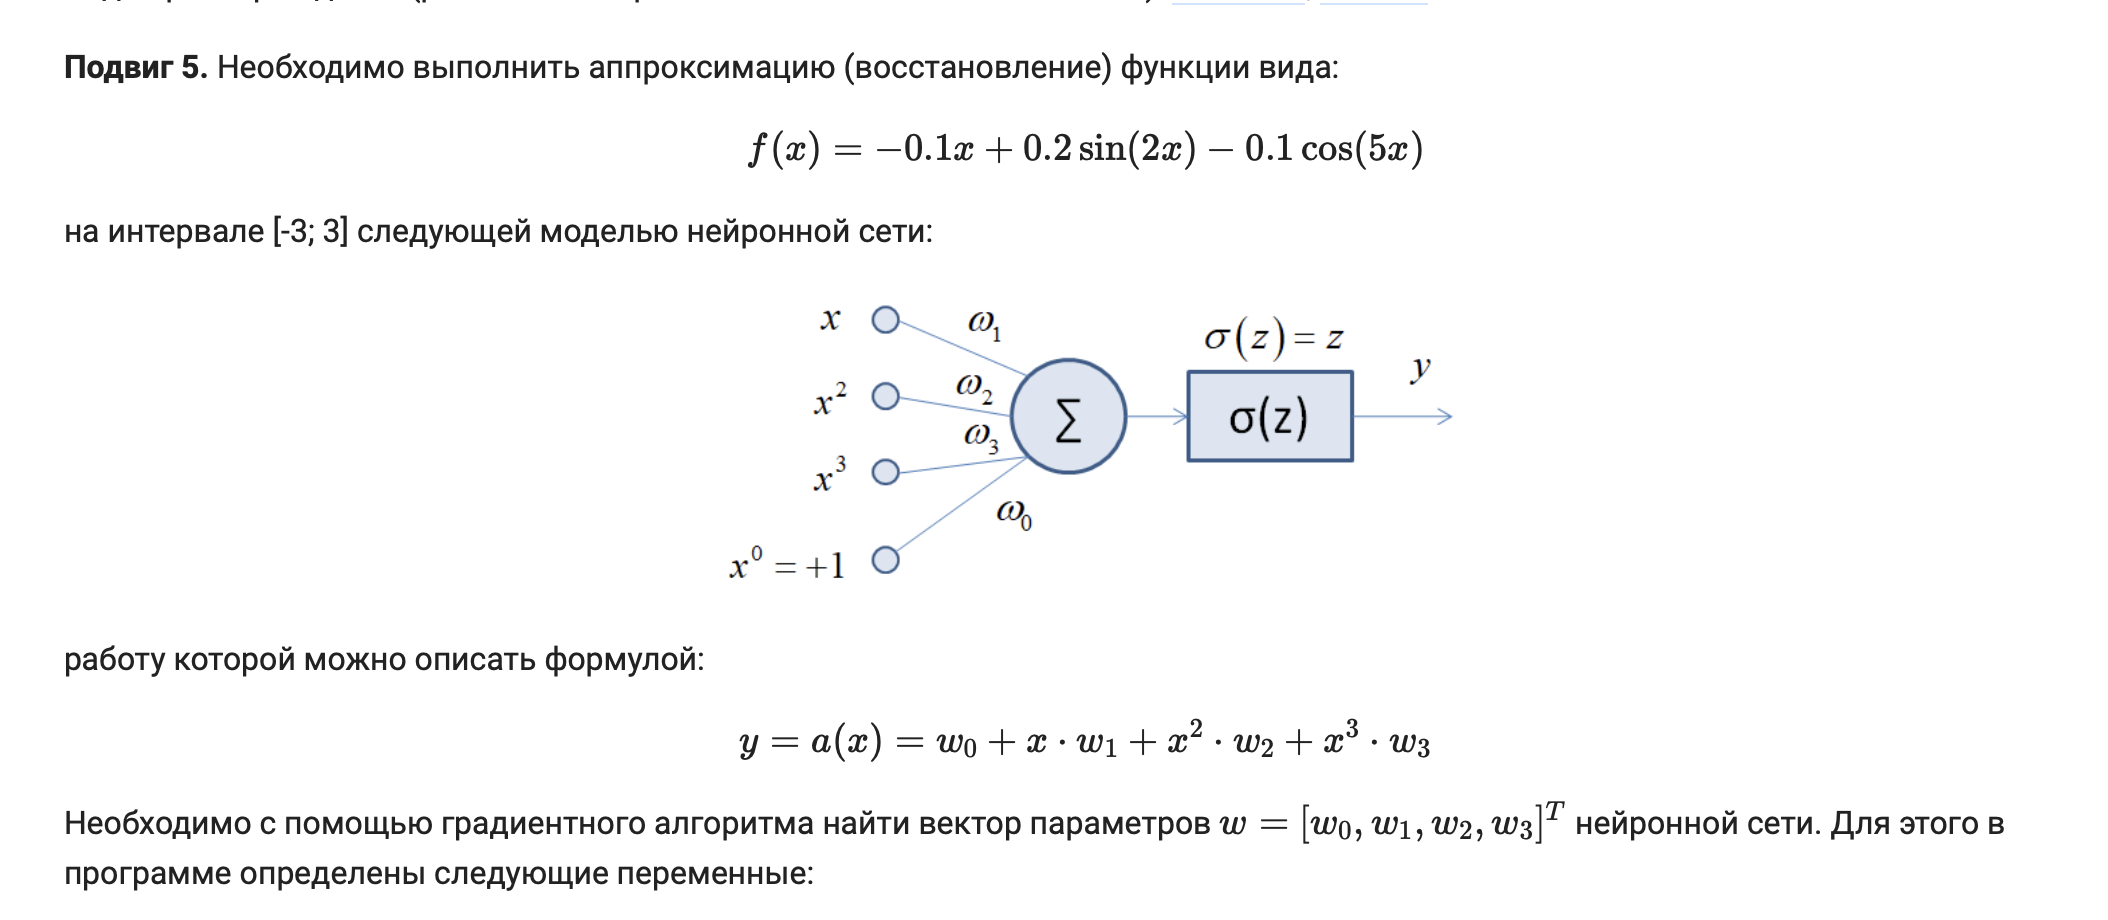
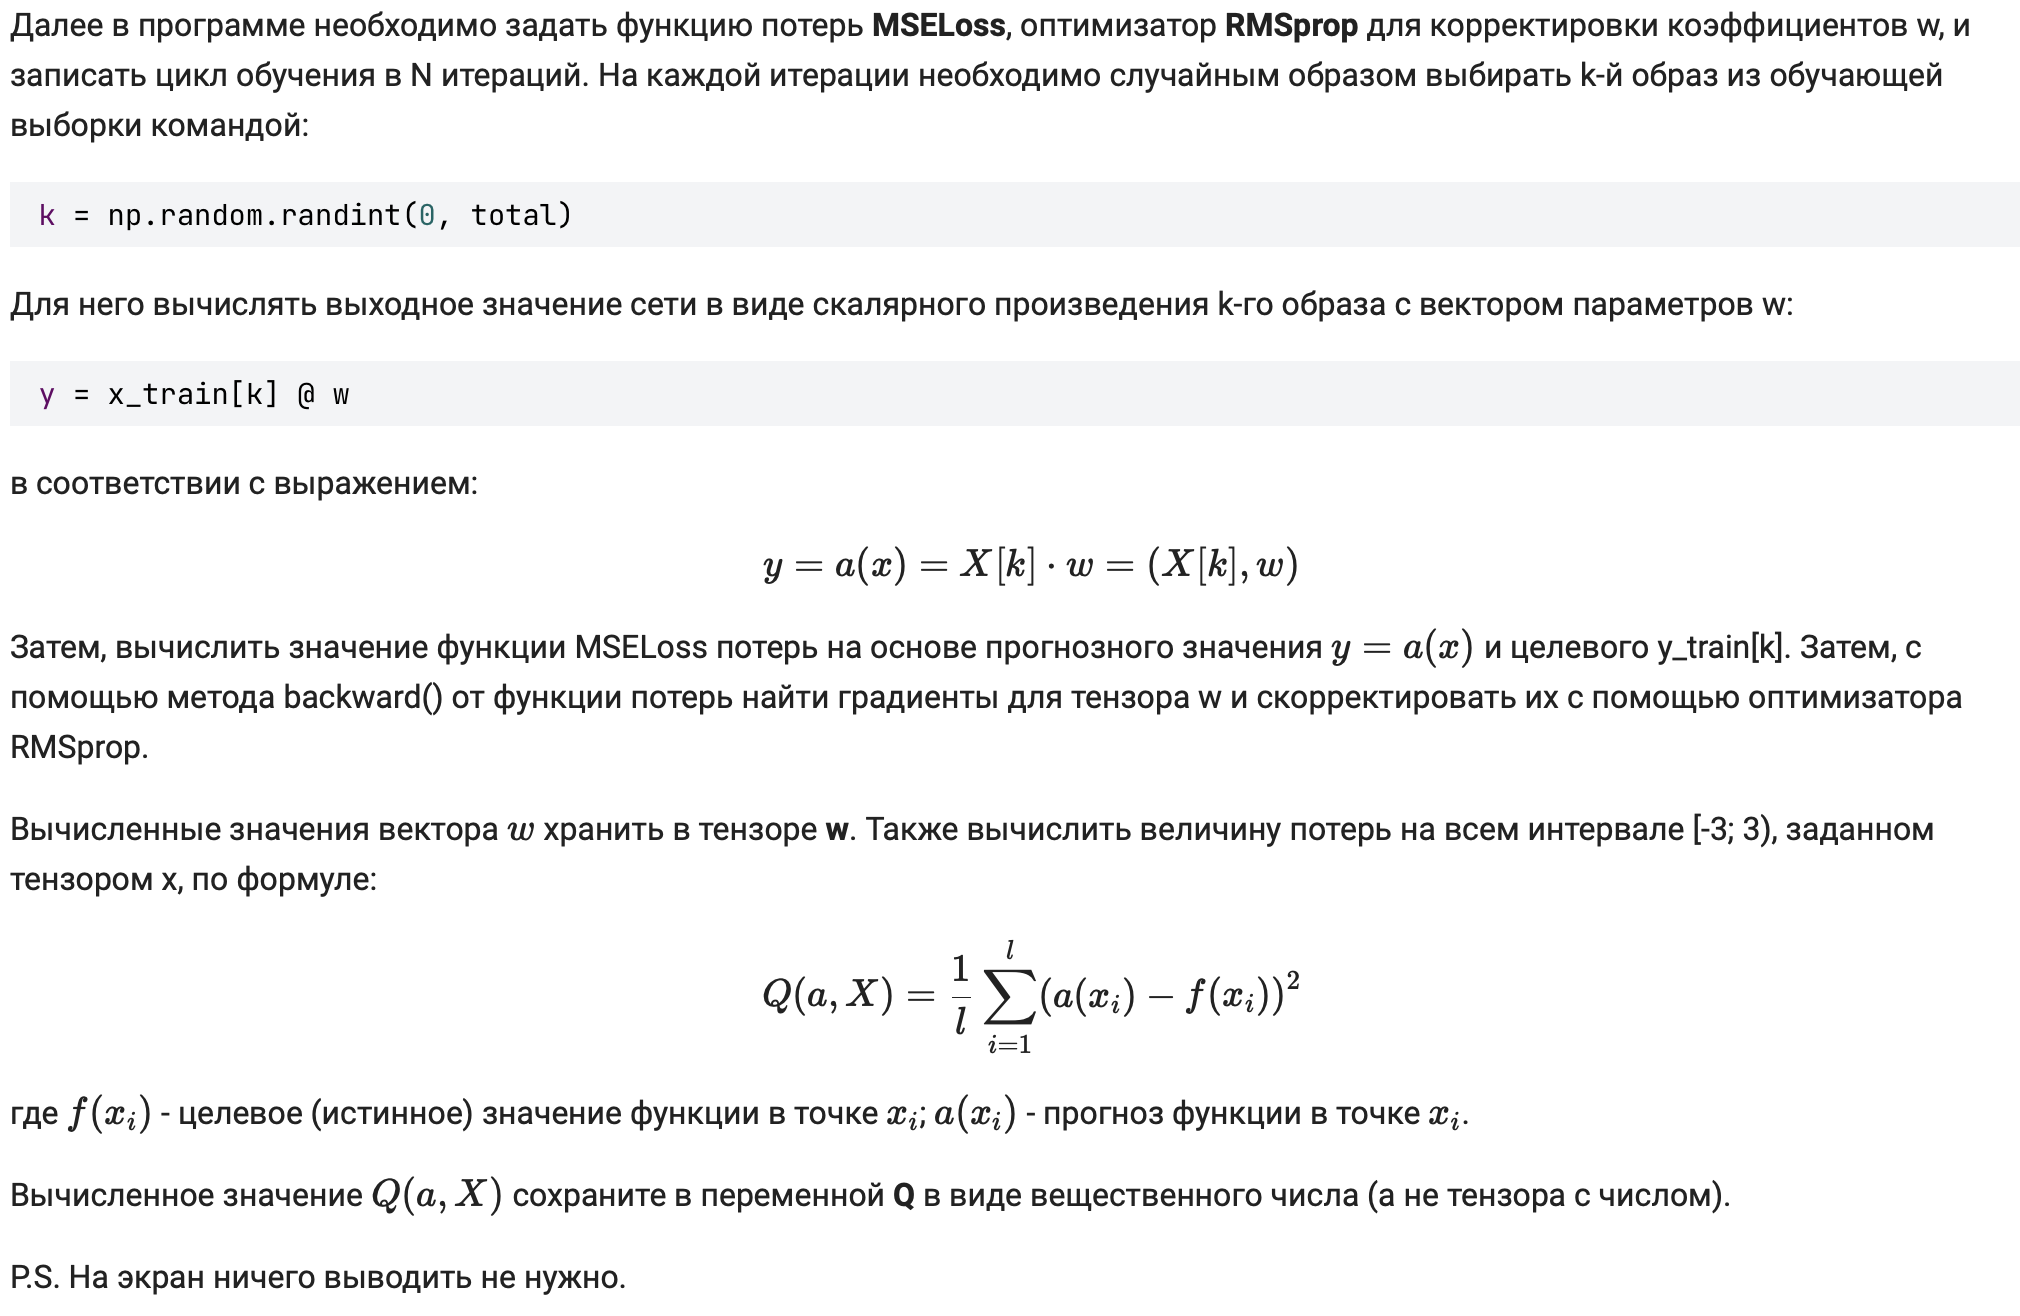

In [11]:
n_features = 4 # число коэффициентов w
x = torch.arange(-3, 3, 0.1)
y_train = -0.1 * x + 0.2 * torch.sin(2 * x) - 0.1 * torch.cos(5 * x)
x_train = torch.tensor([[_x ** _n for _n in range(n_features)] for _x in x])

w = torch.FloatTensor(n_features).uniform_(-1e-5, 1e-5)
w.requires_grad_(True)

total = len(y_train)
lr = 0.01 # шаг обучения
N = 1000 # число итераций алгоритма SGD

np.random.seed(1) # установка "зерна" генератора датчика случайных чисел

# здесь продолжайте программу
loss_func = torch.nn.MSELoss()
optimizer = optim.RMSprop(params=[w], lr=lr)

for i in range(N):
    k = np.random.randint(0, total)
    x = x_train[k]

    y = x @ w
    loss = loss_func(y, y_train[k])
    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

Q = torch.mean((x_train @ w - y_train) ** 2).item()
Q

0.02908707596361637

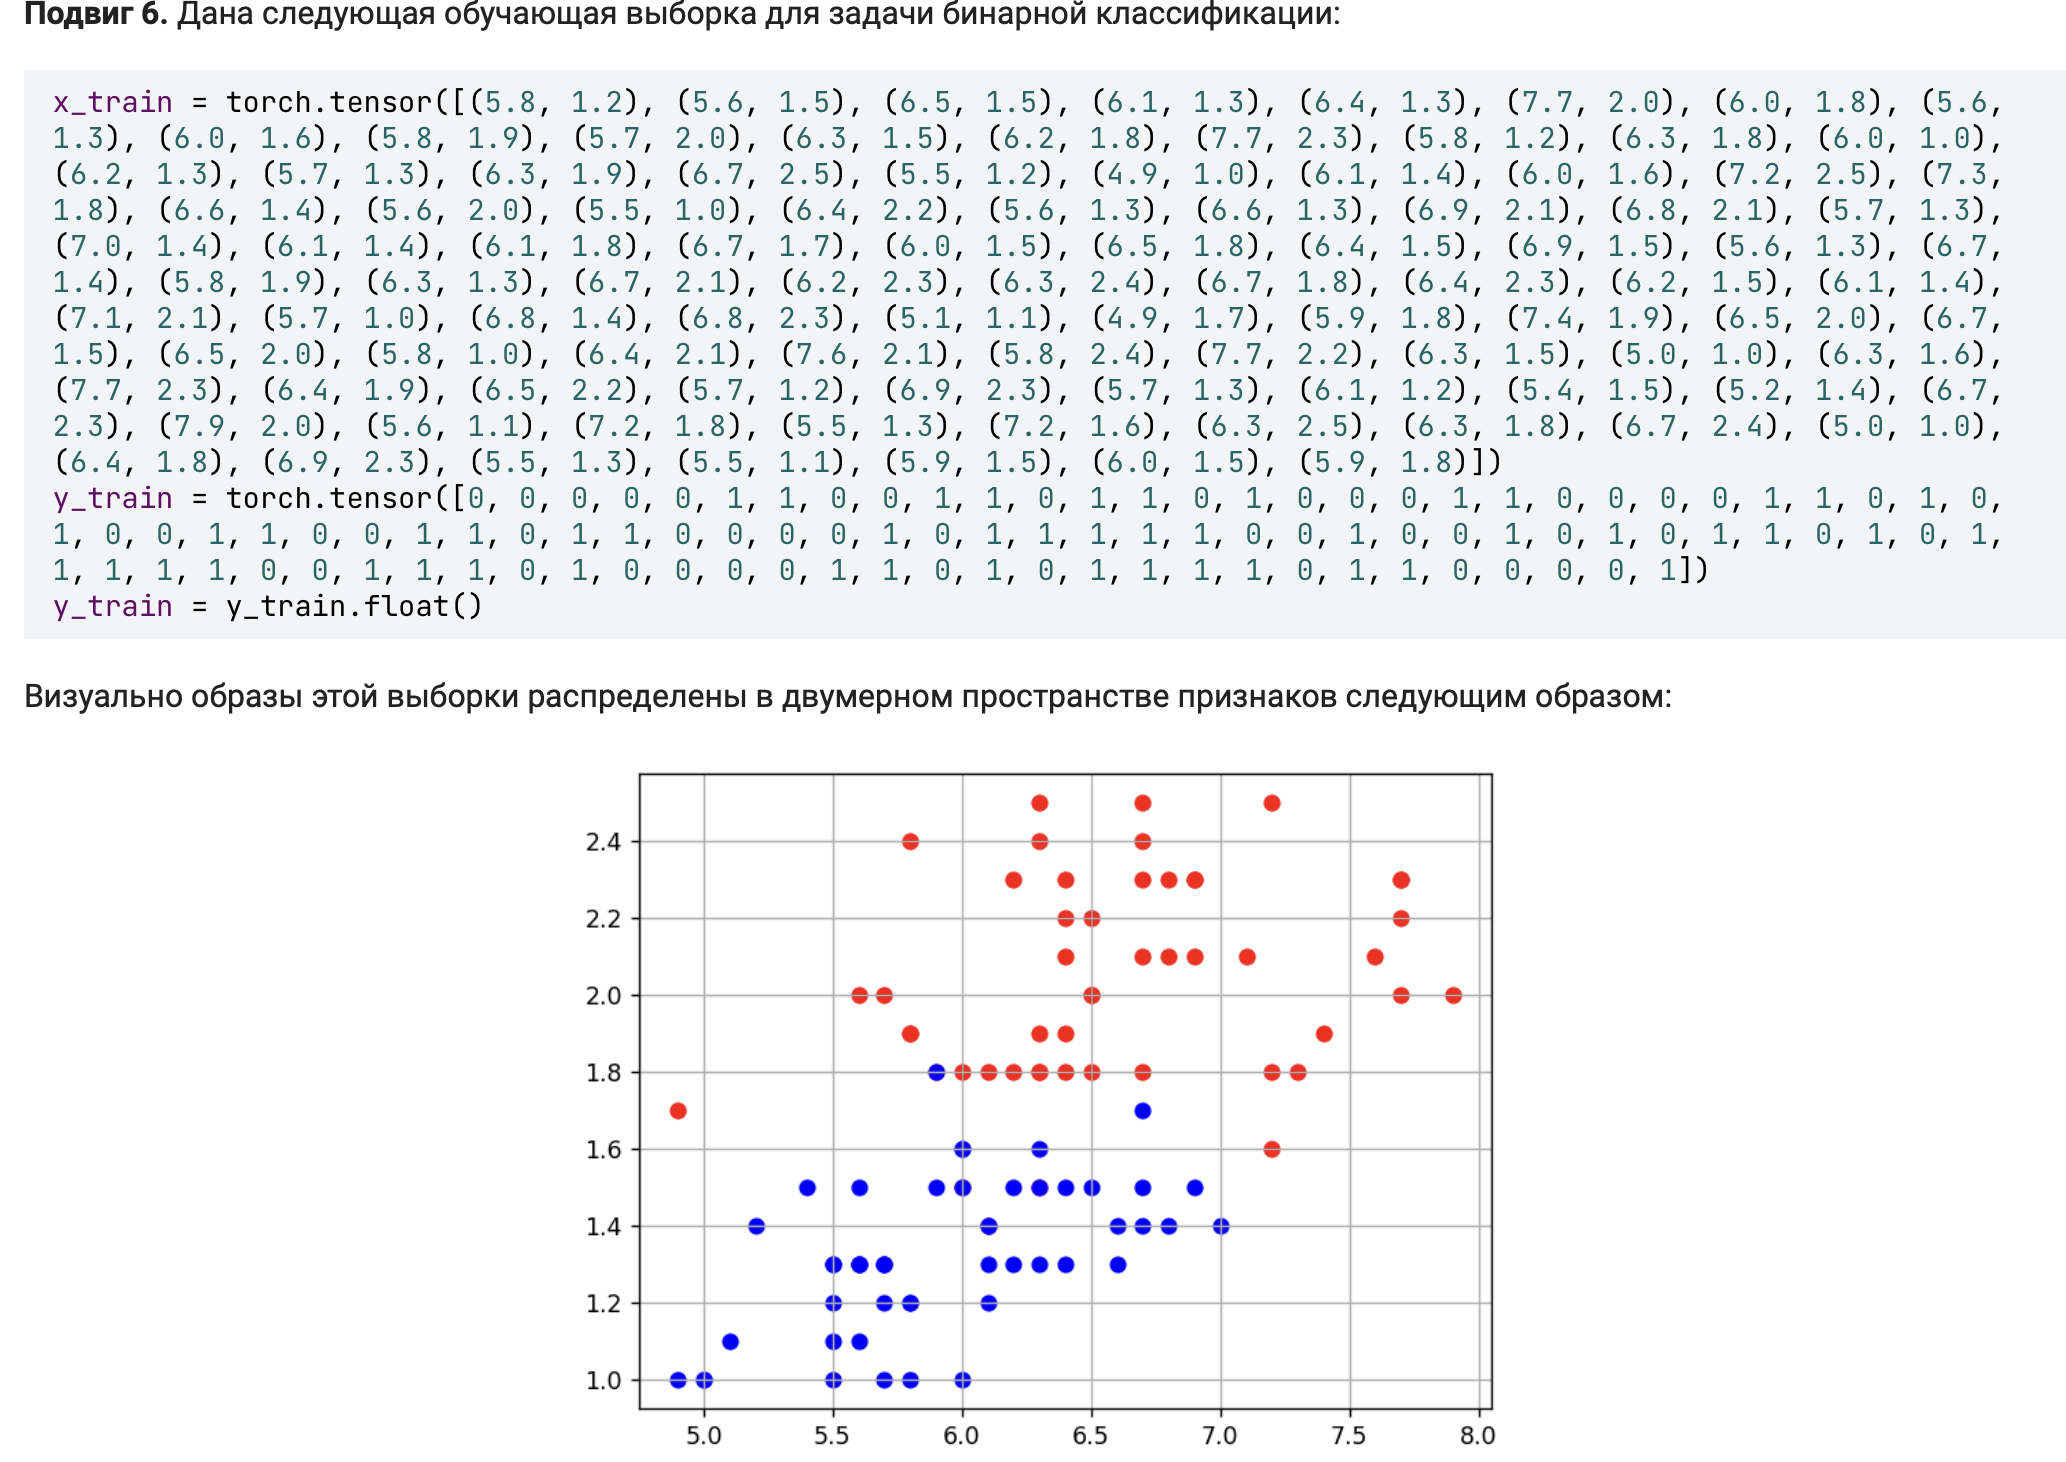
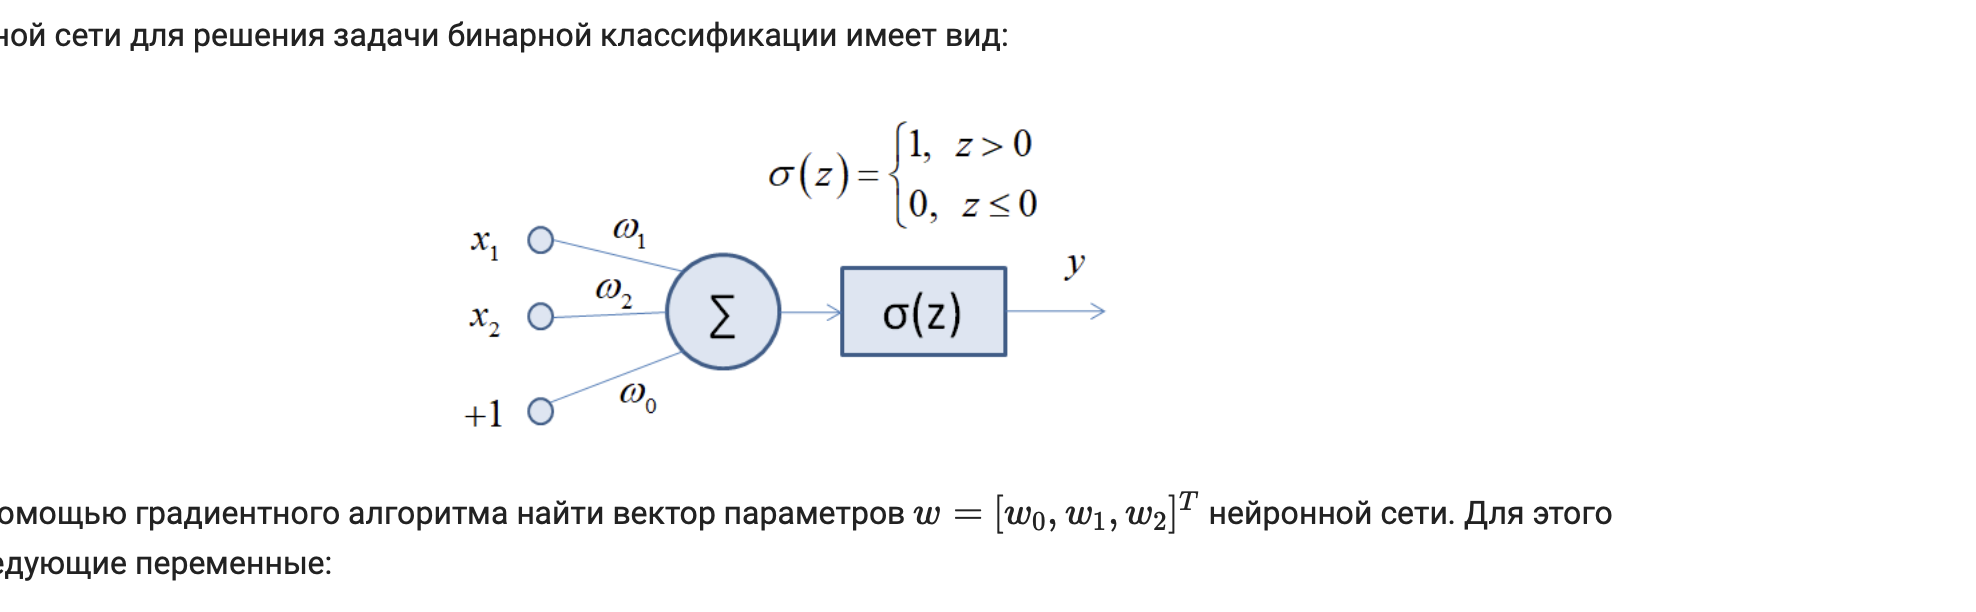
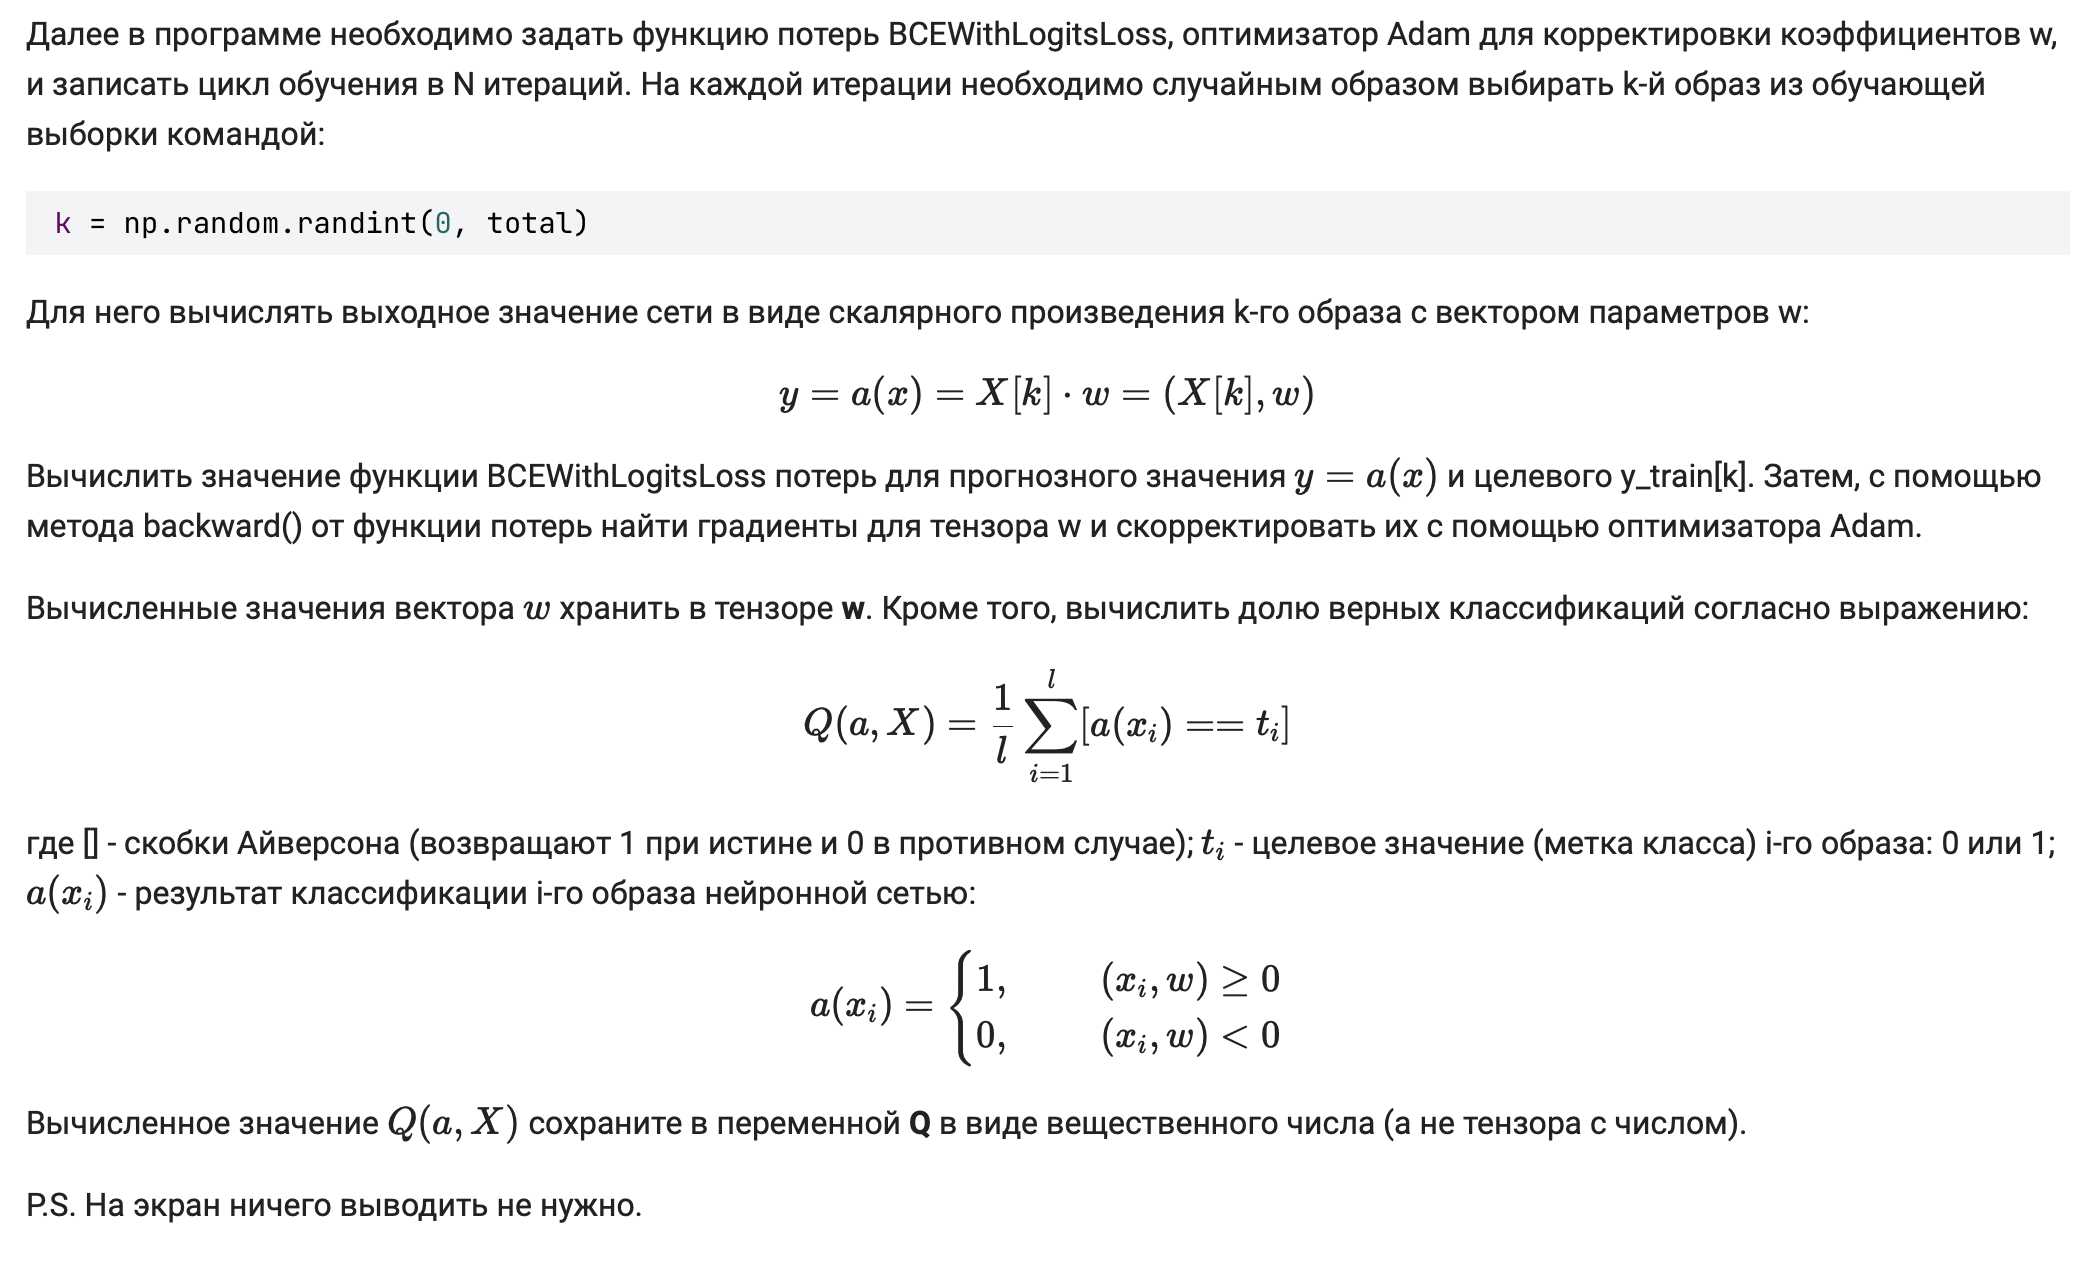

In [22]:
x_train = torch.tensor([(5.8, 1.2), (5.6, 1.5), (6.5, 1.5), (6.1, 1.3), (6.4, 1.3), (7.7, 2.0), (6.0, 1.8), (5.6, 1.3), (6.0, 1.6), (5.8, 1.9), (5.7, 2.0), (6.3, 1.5), (6.2, 1.8), (7.7, 2.3), (5.8, 1.2), (6.3, 1.8), (6.0, 1.0), (6.2, 1.3), (5.7, 1.3), (6.3, 1.9), (6.7, 2.5), (5.5, 1.2), (4.9, 1.0), (6.1, 1.4), (6.0, 1.6), (7.2, 2.5), (7.3, 1.8), (6.6, 1.4), (5.6, 2.0), (5.5, 1.0), (6.4, 2.2), (5.6, 1.3), (6.6, 1.3), (6.9, 2.1), (6.8, 2.1), (5.7, 1.3), (7.0, 1.4), (6.1, 1.4), (6.1, 1.8), (6.7, 1.7), (6.0, 1.5), (6.5, 1.8), (6.4, 1.5), (6.9, 1.5), (5.6, 1.3), (6.7, 1.4), (5.8, 1.9), (6.3, 1.3), (6.7, 2.1), (6.2, 2.3), (6.3, 2.4), (6.7, 1.8), (6.4, 2.3), (6.2, 1.5), (6.1, 1.4), (7.1, 2.1), (5.7, 1.0), (6.8, 1.4), (6.8, 2.3), (5.1, 1.1), (4.9, 1.7), (5.9, 1.8), (7.4, 1.9), (6.5, 2.0), (6.7, 1.5), (6.5, 2.0), (5.8, 1.0), (6.4, 2.1), (7.6, 2.1), (5.8, 2.4), (7.7, 2.2), (6.3, 1.5), (5.0, 1.0), (6.3, 1.6), (7.7, 2.3), (6.4, 1.9), (6.5, 2.2), (5.7, 1.2), (6.9, 2.3), (5.7, 1.3), (6.1, 1.2), (5.4, 1.5), (5.2, 1.4), (6.7, 2.3), (7.9, 2.0), (5.6, 1.1), (7.2, 1.8), (5.5, 1.3), (7.2, 1.6), (6.3, 2.5), (6.3, 1.8), (6.7, 2.4), (5.0, 1.0), (6.4, 1.8), (6.9, 2.3), (5.5, 1.3), (5.5, 1.1), (5.9, 1.5), (6.0, 1.5), (5.9, 1.8)])
y_train = torch.tensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1])
y_train = y_train.float()

total = len(y_train) # размер обучающей выборки
n_features = 3 # число параметров w0, w1, w2
lr = 0.1 # шаг обучения
N = 500 # число итераций градиентного алгоритма

np.random.seed(1) # установка "зерна" генератора датчика случайных чисел

X = torch.ones(total, 3)
X[:, 1:3] = x_train # матрица формата [(1, x11, x12), (1, x21, x22), ..., (1, xn1, xn2)]

w = torch.empty(n_features).uniform_(-1e-5, 1e-5) # начальные значения вектора w
w.requires_grad_(True)

# здесь продолжайте программу
loss_func = torch.nn.BCEWithLogitsLoss()
optimizer = optim.Adam(params=[w], lr = lr)

for i in range(N):
    k = np.random.randint(0, total)
    xi = X[k]
    yi = y_train[k]

    pred = xi @ w
    loss = loss_func(pred, yi)
    loss.backward()

    optimizer.step()
    optimizer.zero_grad()
preds = X @ w
Q = torch.mean((torch.where(preds >= 0, torch.FloatTensor([1]), torch.FloatTensor([0])) == y_train).float())
Q

tensor(0.9300)

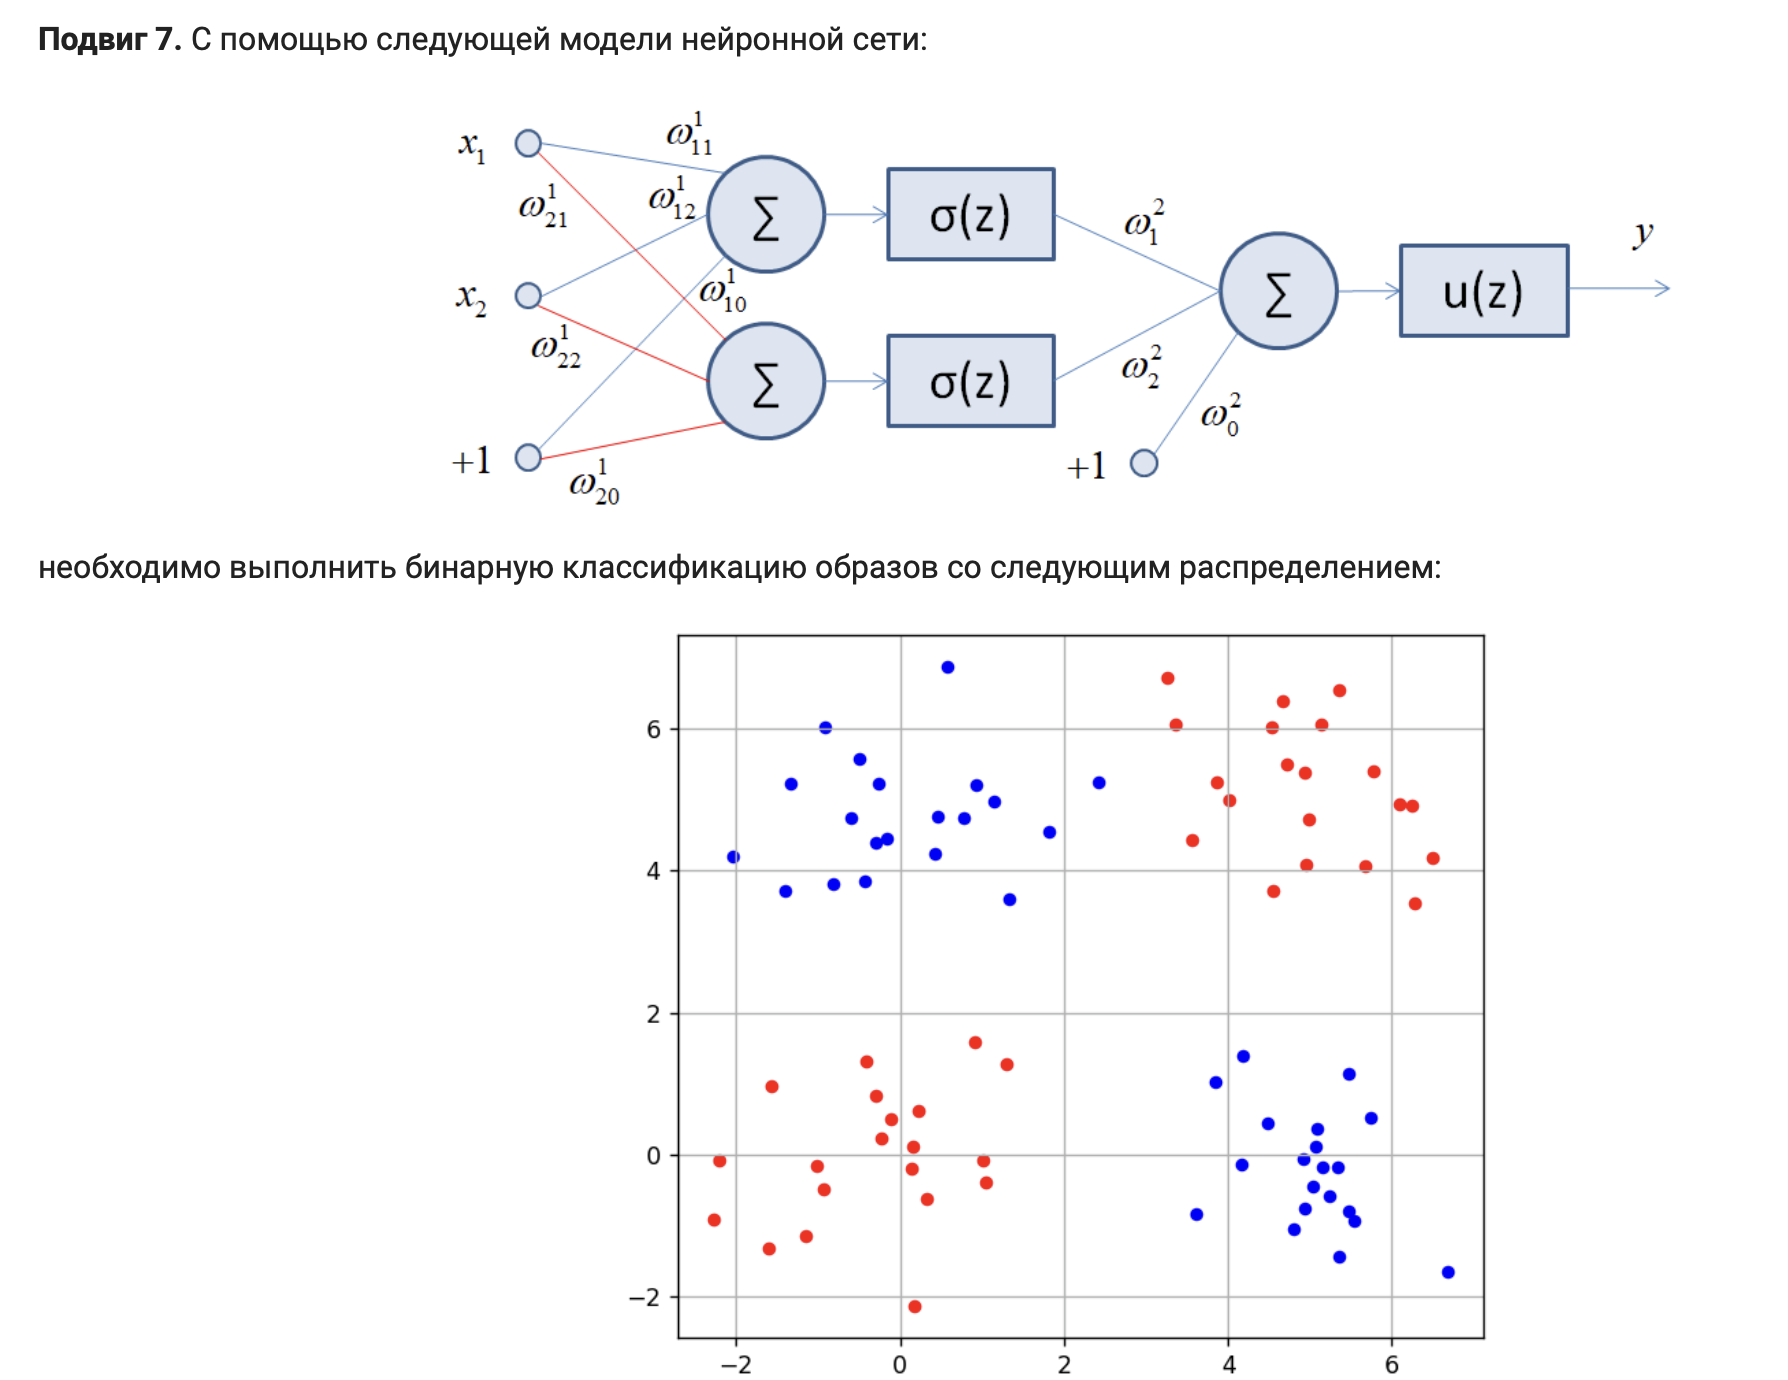
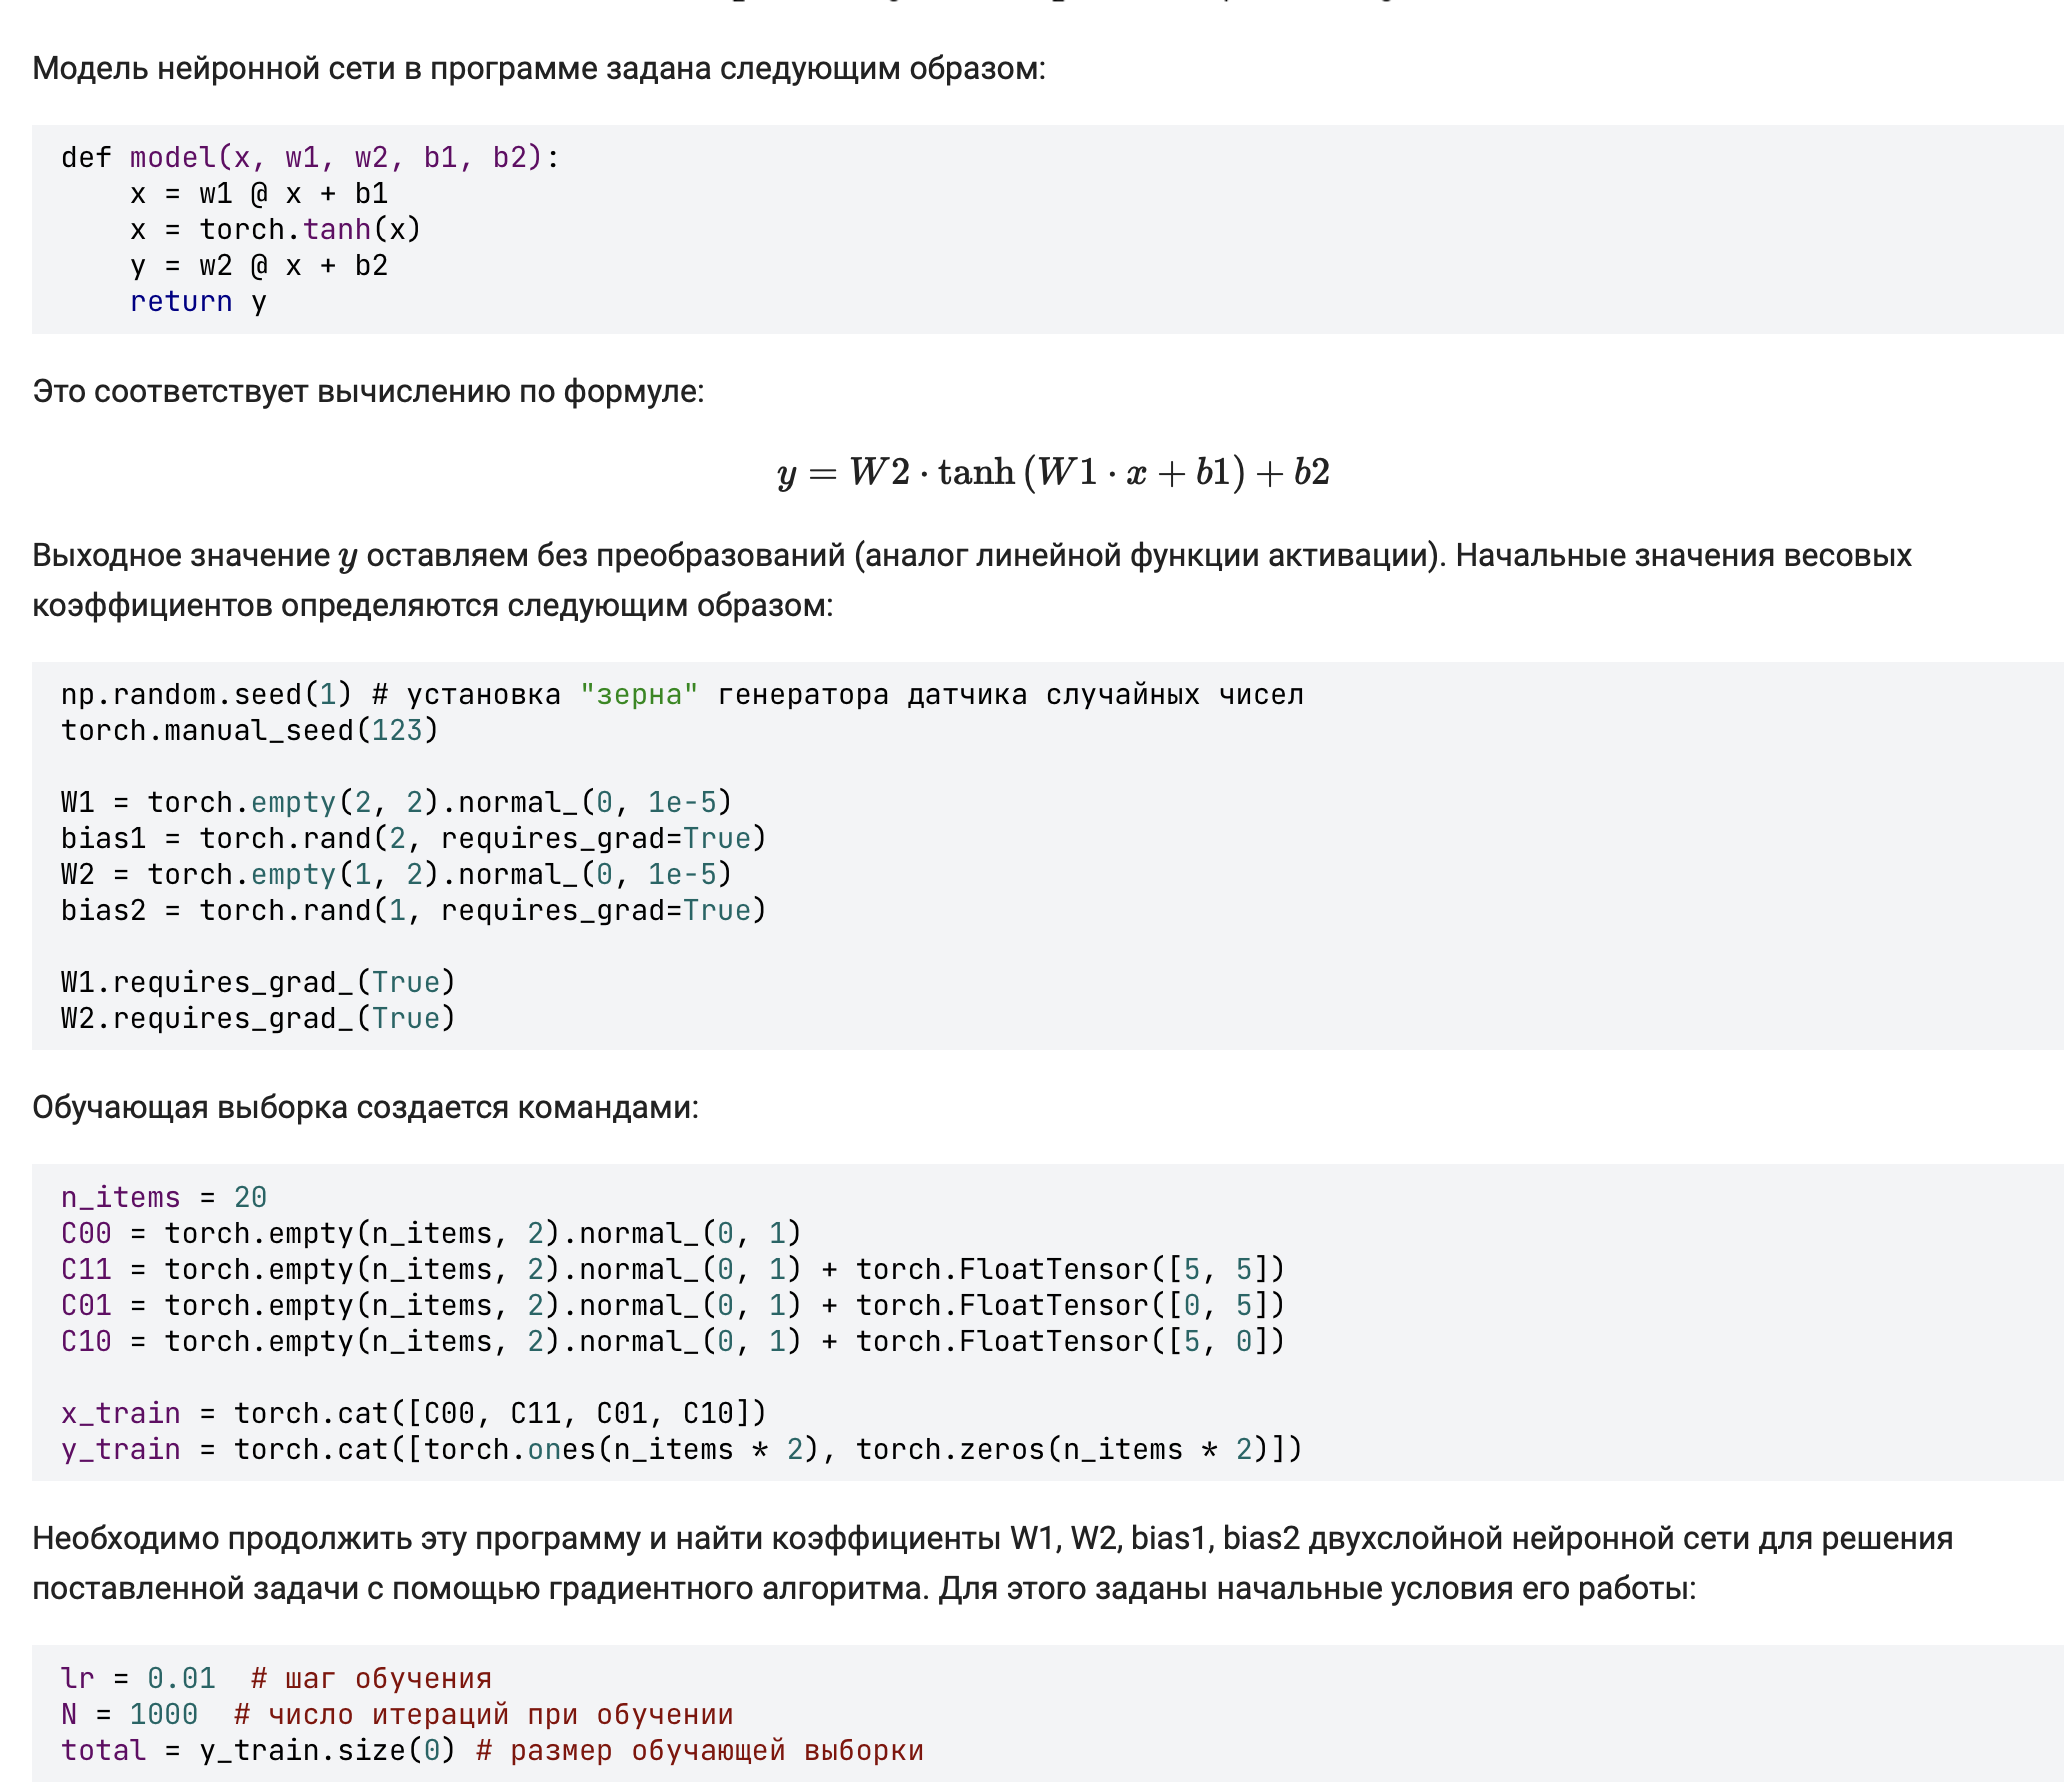
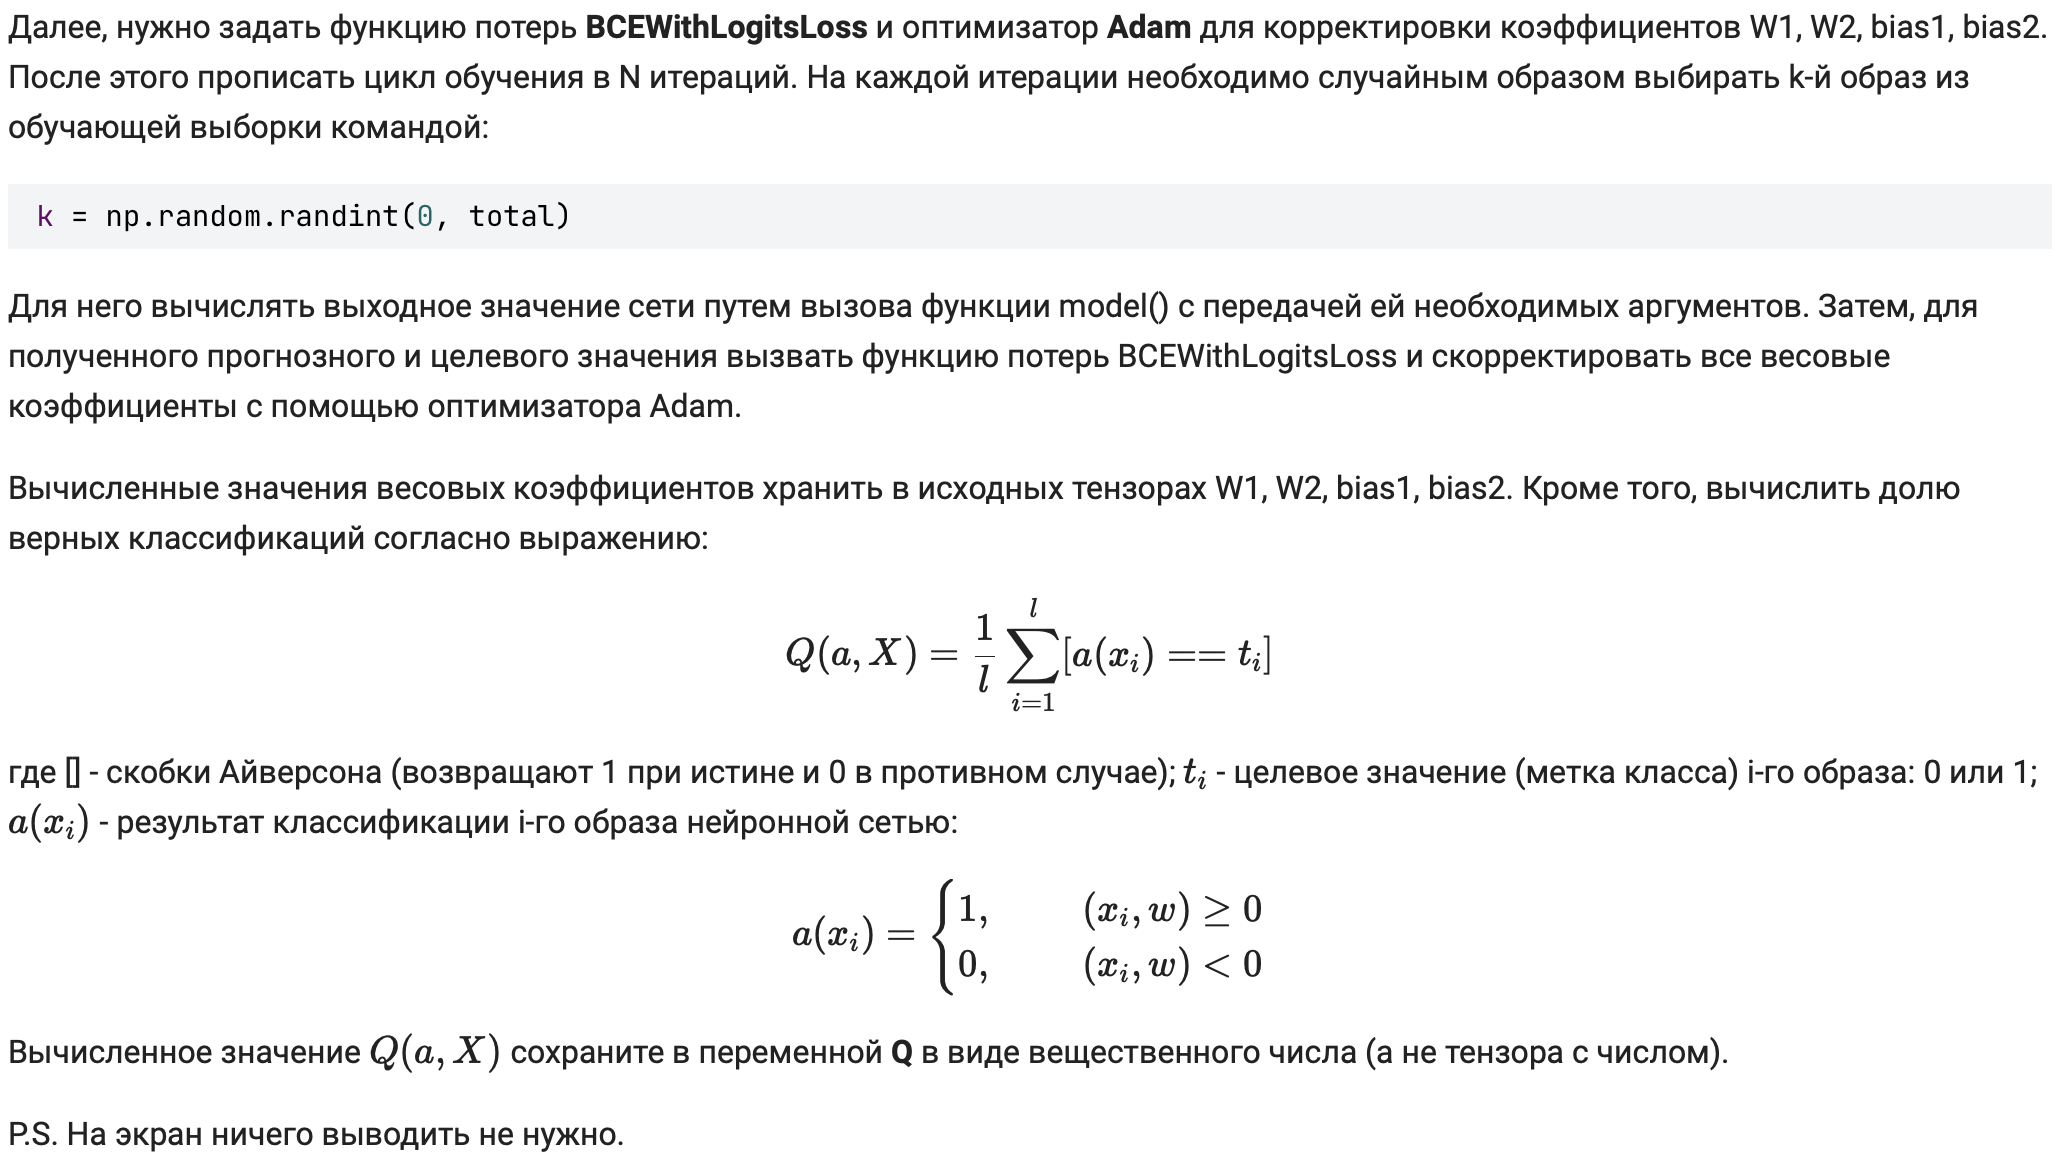

In [28]:
def model(x, w1, w2, b1, b2):
    x = w1 @ x + b1
    x = torch.tanh(x)
    x = w2 @ x + b2
    return x


np.random.seed(1) # установка "зерна" генератора датчика случайных чисел
torch.manual_seed(123)

W1 = torch.empty(2, 2).normal_(0, 1e-5)
bias1 = torch.rand(2, requires_grad=True)
W2 = torch.empty(1, 2).normal_(0, 1e-5)
bias2 = torch.rand(1, requires_grad=True)

W1.requires_grad_(True)
W2.requires_grad_(True)

# обучающая выборка
n_items = 20
C00 = torch.empty(n_items, 2).normal_(0, 1)
C11 = torch.empty(n_items, 2).normal_(0, 1) + torch.FloatTensor([5, 5])
C01 = torch.empty(n_items, 2).normal_(0, 1) + torch.FloatTensor([0, 5])
C10 = torch.empty(n_items, 2).normal_(0, 1) + torch.FloatTensor([5, 0])

x_train = torch.cat([C00, C11, C01, C10])
y_train = torch.cat([torch.ones(n_items * 2), torch.zeros(n_items * 2)])

lr = 0.01  # шаг обучения
N = 1000  # число итераций при обучении
total = y_train.size(0) # размер обучающей выборки

# здесь продолжайте программу
loss_func = torch.nn.BCEWithLogitsLoss()
optimizer = optim.Adam(params=[W1, W2, bias1, bias2], lr=lr)

for i in range(N):
    k = np.random.randint(0, total)
    xi = x_train[k]
    yi = y_train[k].reshape(-1)

    pred = model(xi, W1, W2, bias1, bias2)
    loss = loss_func(pred, yi)
    loss.backward()

    optimizer.step()
    optimizer.zero_grad()
preds = torch.tensor([model(xx, W1, W2, bias1, bias2) for xx in x_train])
Q = torch.mean((torch.where(preds >= 0, torch.FloatTensor([1]), torch.FloatTensor([0])) == y_train).float()).item()
Q

0.949999988079071